In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from scipy.interpolate import PchipInterpolator

from __future__ import division, print_function, absolute_import

from numpy import cos, inf, zeros, array, exp, conj, nan, isnan, pi, sin, seterr
from numpy.lib.scimath import arcsin

import numpy as np

import sys

EPSILON = sys.float_info.epsilon # typical floating-point calculation error

def make_2x2_array(a, b, c, d, dtype=float):
    """
    Makes a 2x2 numpy array of [[a,b],[c,d]]

    Same as "numpy.array([[a,b],[c,d]], dtype=float)", but ten times faster
    """
    my_array = np.empty((2,2), dtype=dtype)
    my_array[0,0] = a
    my_array[0,1] = b
    my_array[1,0] = c
    my_array[1,1] = d
    return my_array

def is_forward_angle(n, theta):
    """
    if a wave is traveling at angle theta from normal in a medium with index n,
    calculate whether or not this is the forward-traveling wave (i.e., the one
    going from front to back of the stack, like the incoming or outgoing waves,
    but unlike the reflected wave).
    
    For real n & theta, the criterion is simply
    -pi/2 < theta < pi/2, but for complex n & theta, it's more complicated.
    See https://arxiv.org/abs/1603.02720 appendix D.
    
    If theta is the forward angle, then (pi-theta) is the backward angle and vice-versa.
    """
    assert n.real * n.imag >= 0, ("For materials with gain, it's ambiguous which "
                                  "beam is incoming vs outgoing. See "
                                  "https://arxiv.org/abs/1603.02720 Appendix C.\n"
                                  "n: " + str(n) + "   angle: " + str(theta))
    ncostheta = n * cos(theta)
    if abs(ncostheta.imag) > 100 * EPSILON:
        # Either evanescent decay or lossy medium. Either way, the one that
        # decays is the forward-moving wave
        answer = (ncostheta.imag > 0)
    else:
        # Forward is the one with positive Poynting vector
        # Poynting vector is Re[n cos(theta)] for s-polarization or
        # Re[n cos(theta*)] for p-polarization, but it turns out they're consistent
        # so I'll just assume s then check both below
        answer = (ncostheta.real > 0)
    # convert from numpy boolean to the normal Python boolean
    answer = bool(answer)
    # double-check the answer ... can't be too careful!
    error_string = ("It's not clear which beam is incoming vs outgoing. Weird"
                    " index maybe?\n"
                    "n: " + str(n) + "   angle: " + str(theta))
    if answer is True:
        assert ncostheta.imag > -100 * EPSILON, error_string
        assert ncostheta.real > -100 * EPSILON, error_string
        assert (n * cos(theta.conjugate())).real > -100 * EPSILON, error_string
    else:
        assert ncostheta.imag < 100 * EPSILON, error_string
        assert ncostheta.real < 100 * EPSILON, error_string
        assert (n * cos(theta.conjugate())).real < 100 * EPSILON, error_string
    return answer

def snell(n_1, n_2, th_1):
    """
    return angle theta in layer 2 with refractive index n_2, assuming
    it has angle th_1 in layer with refractive index n_1. Use Snell's law. Note
    that "angles" may be complex!!
    """
    # Important that the arcsin here is numpy.lib.scimath.arcsin, not
    # numpy.arcsin! (They give different results e.g. for arcsin(2).)
    th_2_guess = arcsin(n_1*np.sin(th_1) / n_2)
    if is_forward_angle(n_2, th_2_guess):
        return th_2_guess
    else:
        return pi - th_2_guess #gives angle of reflected wave -- Bryant 

def list_snell(n_list, th_0):
    """
    return list of angle theta in each layer based on angle th_0 in layer 0,
    using Snell's law. n_list is index of refraction of each layer. Note that
    "angles" may be complex!!
    """
    # Important that the arcsin here is numpy.lib.scimath.arcsin, not
    # numpy.arcsin! (They give different results e.g. for arcsin(2).)
    angles = arcsin(n_list[0]*np.sin(th_0) / n_list)
    # The first and last entry need to be the forward angle (the intermediate
    # layers don't matter, see https://arxiv.org/abs/1603.02720 Section 5)
    if not is_forward_angle(n_list[0], angles[0]):
        angles[0] = pi - angles[0]
    if not is_forward_angle(n_list[-1], angles[-1]):
        angles[-1] = pi - angles[-1]
    return angles


def interface_r(polarization, n_i, n_f, th_i, th_f): #calculates the reflection coefficient at the interface between two layers
    """
    reflection amplitude (from Fresnel equations)

    polarization is either "s" or "p" for polarization

    n_i, n_f are (complex) refractive index for incident and final

    th_i, th_f are (complex) propegation angle for incident and final
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if polarization == 's':
        return ((n_i * cos(th_i) - n_f * cos(th_f)) /
                (n_i * cos(th_i) + n_f * cos(th_f)))
    elif polarization == 'p':
        return ((n_f * cos(th_i) - n_i * cos(th_f)) /
                (n_f * cos(th_i) + n_i * cos(th_f)))
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def interface_t(polarization, n_i, n_f, th_i, th_f): #calculates the transmission coefficient at the interface between two layers
    """
    transmission amplitude (frem Fresnel equations)

    polarization is either "s" or "p" for polarization

    n_i, n_f are (complex) refractive index for incident and final

    th_i, th_f are (complex) propegation angle for incident and final
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if polarization == 's':
        return 2 * n_i * cos(th_i) / (n_i * cos(th_i) + n_f * cos(th_f))
    elif polarization == 'p':
        return 2 * n_i * cos(th_i) / (n_f * cos(th_i) + n_i * cos(th_f))
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def R_from_r(r):
    """
    Calculate reflected power R, starting with reflection amplitude r.
    """
    return abs(r)**2

def T_from_t(pol, t, n_i, n_f, th_i, th_f):
    """
    Calculate transmitted power T, starting with transmission amplitude t.

    n_i,n_f are refractive indices of incident and final medium.

    th_i, th_f are (complex) propegation angles through incident & final medium
    (in radians, where 0=normal). "th" stands for "theta".

    In the case that n_i,n_f,th_i,th_f are real, formulas simplify to
    T=|t|^2 * (n_f cos(th_f)) / (n_i cos(th_i)).

    See https://arxiv.org/abs/1603.02720 for discussion of formulas
    """
    if pol == 's':
        return abs(t**2) * (((n_f*cos(th_f)).real) / (n_i*cos(th_i)).real)
    elif pol == 'p':
        return abs(t**2) * (((n_f*conj(cos(th_f))).real) /
                                (n_i*conj(cos(th_i))).real)
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def power_entering_from_r(pol, r, n_i, th_i):
    """
    Calculate the power entering the first interface of the stack, starting with
    reflection amplitude r. Normally this equals 1-R, but in the unusual case
    that n_i is not real, it can be a bit different than 1-R. See
    https://arxiv.org/abs/1603.02720

    n_i is refractive index of incident medium.

    th_i is (complex) propagation angle through incident medium
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if pol == 's':
        return ((n_i*cos(th_i)*(1+conj(r))*(1-r)).real
                     / (n_i*cos(th_i)).real)
    elif pol == 'p':
        return ((n_i*conj(cos(th_i))*(1+r)*(1-conj(r))).real
                      / (n_i*conj(cos(th_i))).real)
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def interface_R(polarization, n_i, n_f, th_i, th_f):
    """
    Fraction of light intensity reflected at an interface.
    """
    r = interface_r(polarization, n_i, n_f, th_i, th_f)
    return R_from_r(r)

def interface_T(polarization, n_i, n_f, th_i, th_f):
    """
    Fraction of light intensity transmitted at an interface.
    """
    t = interface_t(polarization, n_i, n_f, th_i, th_f)
    return T_from_t(polarization, t, n_i, n_f, th_i, th_f)

def coh_tmm(pol, n_list, d_list, th_0, lam_vac):
    """
    Main "coherent transfer matrix method" calc. Given parameters of a stack,
    calculates everything you could ever want to know about how light
    propagates in it. (If performance is an issue, you can delete some of the
    calculations without affecting the rest.)

    pol is light polarization, "s" or "p".

    n_list is the list of refractive indices, in the order that the light would
    pass through them. The 0'th element of the list should be the semi-infinite
    medium from which the light enters, the last element should be the semi-
    infinite medium to which the light exits (if any exits).

    th_0 is the angle of incidence: 0 for normal, pi/2 for glancing(grazing incidence).
    Remember, for a dissipative incoming medium (n_list[0] is not real), th_0
    should be complex so that n0 sin(th0) is real (intensity is constant as
    a function of lateral position).

    d_list is the list of layer thicknesses (front to back). Should correspond
    one-to-one with elements of n_list. First and last elements should be "inf".

    lam_vac is vacuum wavelength of the light.
    
    This function, like everything else in the package, implicitly requires you
    to pick a unit of length.You can use any unit, but keep it consistent.
    For example, if you input the wavelength in nanometers, then you must also
    input the layer thicknesses in nanometers. And then any angular wavenumber
    outputs will be in radians per nanometer, and any absorption outputs will
    be in (fraction of incoming light power per nanometer of depth), and so on.

    Then the function outputs the following as a dictionary (see
    https://arxiv.org/abs/1603.02720 for details)

    * r--reflection amplitude
    * t--transmission amplitude
    * R--reflected wave power (as fraction of incident)
    * T--transmitted wave power (as fraction of incident)
    * power_entering--Power entering the first layer, usually (but not always)
      equal to 1-R (see https://arxiv.org/abs/1603.02720 ).
    * vw_list-- n'th element is [v_n,w_n], the forward- and backward-traveling
      amplitudes, respectively, in the n'th medium just after interface with
      (n-1)st medium.
    * kz_list--normal component of complex angular wavenumber for
      forward-traveling wave in each layer.
    * th_list--(complex) propagation angle (in radians) in each layer
    * pol, n_list, d_list, th_0, lam_vac--same as input

    """
    # Convert lists to numpy arrays if they're not already.
    n_list = array(n_list)
    d_list = array(d_list, dtype=float)

    # Input tests
    if ((hasattr(lam_vac, 'size') and lam_vac.size > 1)
          or (hasattr(th_0, 'size') and th_0.size > 1)):
        raise ValueError('This function is not vectorized; you need to run one '
                         'calculation at a time (1 wavelength, 1 angle, etc.)')
    if (n_list.ndim != 1) or (d_list.ndim != 1) or (n_list.size != d_list.size):
        raise ValueError("Problem with n_list or d_list!")
    assert d_list[0] == d_list[-1] == inf, 'd_list must start and end with inf!'
    assert abs((n_list[0]*np.sin(th_0)).imag) < 100*EPSILON, 'Error in n0 or th0!'
    assert is_forward_angle(n_list[0], th_0), 'Error in n0 or th0!'
    num_layers = n_list.size

    # th_list is a list with, for each layer, the angle that the light travels
    # through the layer. Computed with Snell's law. Note that the "angles" may be
    # complex!
    th_list = list_snell(n_list, th_0)

    # kz is the z-component of (complex) angular wavevector for forward-moving (i.e. it's Beta) 
    # wave. Positive imaginary part means decaying.
    kz_list = 2 * np.pi * n_list * cos(th_list) / lam_vac

    # delta is the total phase accrued by traveling through a given layer.
    # Ignore warning about inf multiplication
    olderr = seterr(invalid='ignore')
    delta = kz_list * d_list
    seterr(**olderr)

    # For a very opaque layer, reset delta to avoid divide-by-0 and similar
    # errors. The criterion imag(delta) > 35 corresponds to single-pass
    # transmission < 1e-30 --- small enough that the exact value doesn't
    # matter.
    for i in range(1, num_layers-1):
        if delta[i].imag > 35:
            delta[i] = delta[i].real + 35j
            if 'opacity_warning' not in globals():
                global opacity_warning
                opacity_warning = True
                print("Warning: Layers that are almost perfectly opaque "
                      "are modified to be slightly transmissive, "
                      "allowing 1 photon in 10^30 to pass through. It's "
                      "for numerical stability. This warning will not "
                      "be shown again.")

    # t_list[i,j] and r_list[i,j] are transmission and reflection amplitudes,
    # respectively, coming from i, going to j. Only need to calculate this when
    # j=i+1. (2D array is overkill but helps avoid confusion.)
    t_list = zeros((num_layers, num_layers), dtype=complex)
    r_list = zeros((num_layers, num_layers), dtype=complex)
    for i in range(num_layers-1):
        t_list[i,i+1] = interface_t(pol, n_list[i], n_list[i+1],
                                    th_list[i], th_list[i+1])
        r_list[i,i+1] = interface_r(pol, n_list[i], n_list[i+1],
                                    th_list[i], th_list[i+1])
    # At the interface between the (n-1)st and nth material, let v_n be the
    # amplitude of the wave on the nth side heading forwards (away from the
    # boundary), and let w_n be the amplitude on the nth side heading backwards
    # (towards the boundary). Then (v_n,w_n) = M_n (v_{n+1},w_{n+1}). M_n is
    # M_list[n]. M_0 and M_{num_layers-1} are not defined.
    # My M is a bit different than Sernelius's, but Mtilde is the same.
    M_list = zeros((num_layers, 2, 2), dtype=complex)
    for i in range(1, num_layers-1):
        M_list[i] = (1/t_list[i,i+1]) * np.dot(
            make_2x2_array(exp(-1j*delta[i]), 0, 0, exp(1j*delta[i]),
                           dtype=complex),
            make_2x2_array(1, r_list[i,i+1], r_list[i,i+1], 1, dtype=complex))
    Mtilde = make_2x2_array(1, 0, 0, 1, dtype=complex)
    for i in range(1, num_layers-1):
        Mtilde = np.dot(Mtilde, M_list[i])
    Mtilde = np.dot(make_2x2_array(1, r_list[0,1], r_list[0,1], 1,
                                   dtype=complex)/t_list[0,1], Mtilde)

    # Net complex transmission and reflection amplitudes
    r = Mtilde[1,0]/Mtilde[0,0]
    t = 1/Mtilde[0,0]

    # vw_list[n] = [v_n, w_n]. v_0 and w_0 are undefined because the 0th medium
    # has no left interface.
    vw_list = zeros((num_layers, 2), dtype=complex)
    vw = array([[t],[0]])
    vw_list[-1,:] = np.transpose(vw)
    for i in range(num_layers-2, 0, -1):
        vw = np.dot(M_list[i], vw)
        vw_list[i,:] = np.transpose(vw)

    # Net transmitted and reflected power, as a proportion of the incoming light
    # power.
    R = R_from_r(r)
    T = T_from_t(pol, t, n_list[0], n_list[-1], th_0, th_list[-1])
    power_entering = power_entering_from_r(pol, r, n_list[0], th_0)

    return {'r': r, 't': t, 'R': R, 'T': T, 'power_entering': power_entering,
            'vw_list': vw_list, 'kz_list': kz_list, 'th_list': th_list,
            'pol': pol, 'n_list': n_list, 'd_list': d_list, 'th_0': th_0,
            'lam_vac':lam_vac}

def unpolarized_RT(n_list, d_list, th_0, lam_vac): #input your n_list, thickness list, th_0 is just one value,a nd then loop over the wavelengths
    """
    Calculates reflected and transmitted power for unpolarized light.
    """

    s_data = coh_tmm('s', n_list, d_list, th_0, lam_vac)
    p_data = coh_tmm('p', n_list, d_list, th_0, lam_vac)
    R = (s_data['R'] + p_data['R']) / 2.
    T = (s_data['T'] + p_data['T']) / 2.
    return R, T #reflected power and transmitted power 

    """
    pol is light polarization, "s" or "p".

n_list is the list of refractive indices, in the order that the light would
    pass through them. The 0'th element of the list should be the semi-infinite
    medium from which the light enters, the last element should be the semi-
    infinite medium to which the light exits (if any exits).

th_0 is the angle of incidence: 0 for normal, pi/2 for glancing(grazing incidence).
    Remember, for a dissipative incoming medium (n_list[0] is not real), th_0
    should be complex so that n0 sin(th0) is real (intensity is constant as
    a function of lateral position).

d_list is the list of layer thicknesses (front to back). Should correspond
    one-to-one with elements of n_list. First and last elements should be "inf".

    This function, like everything else in the package, implicitly requires you
    to pick a unit of length.You can use any unit, but keep it consistent.
    For example, if you input the wavelength in nanometers, then you must also
    input the layer thicknesses in nanometers. And then any angular wavenumber
    outputs will be in radians per nanometer, and any absorption outputs will
    be in (fraction of incoming light power per nanometer of depth), and so on.
    """

#silicon n-k data extraction
ref_silicon = r"C:\School Stuff\UC Davis\Leite Lab\Data\si.txt"

# Containers/the columns of your data
wavelength_nm_silicon= []
n_vals_si = []
k_vals_si = []

#extracts data from multiple columns 
with open(ref_silicon , "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline()  # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f: #the first horizontal line is read, so now the file pointer is on line two. It will now to start to loop line by line. 
        if not line.strip():
            continue  # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined 

        wl, n, k = line.split() #the horizontal line is split into columns now, and you WILL alter this for your data file to extract column info line by line(row by row). 
        wavelength_nm_silicon.append(float(wl))
        n_vals_si.append(float(n))
        k_vals_si.append(float(k))

# Read the second file with single column
inter_range = r"C:\School Stuff\UC Davis\Leite Lab\Data\Wavelength Range for Interpolation.txt"
interpolation_range = []
with open(inter_range, "r") as f:
    header = f.readline()  # skip header line
    for line in f:
        if not line.strip():
            continue  # skip empty lines
        value = line.strip()
        interpolation_range.append(float(value))

# Converting my reference silicon data from lists --> numpy arrays so that they can be used for calculations. 
wavelengths1= np.array(wavelength_nm_silicon) 
n_data_si = np.array(n_vals_si) #n & k data of silicon 
k_data_si = np.array(k_vals_si) 

# Create the splines for fitting 
pchip_n = PchipInterpolator(wavelengths1, n_data_si)
pchip_k = PchipInterpolator(wavelengths1, k_data_si)

# Interpolate at any x values(wavelengths) within your range
wavelengths_exp = np.array(interpolation_range)  #This is the wavelength range from margaret's data 
n_new_si = pchip_n(wavelengths_exp) #this is now going to use the wavelength range as the input for the interpolation functions 
k_new_si = pchip_k(wavelengths_exp)

#extracting Margaret's experimental Data

md_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\am2c14613_si_001.txt"

#initialize the lists
wl_exp = []
e1_Mo = []
e2_Mo = []
e1_Ru = []
e2_Ru = []
e1_Ta = []
e2_Ta = []
e1_W = []
e2_W = []
e1_MoO3 = []
e2_MoO3 = []
e1_RuO2 = []
e2_RuO2 = []
e1_Ta2O5 = []
e2_Ta2O5 = []
e1_WO3 = []
e2_WO3 = []

with open(md_data, 'r') as f:
    header = f.readline() #stores header information and disregards it 
    for line in f:
        if not line.strip(): #if there's nothing in the line, skip it 
            continue 

        #Split the text file into columns, the file is split by tabs, not spaces
        values = line.split('\t') #if it was split by spaces the argument would be empty 
                                  #since there are 17 columns the index goes from 0 --> 16 

        wl_exp.append(float(values[0]))
        e1_Mo.append(float(values[1]))
        e2_Mo.append(float(values[2]))
        e1_Ru.append(float(values[3]))
        e2_Ru.append(float(values[4]))
        e1_Ta.append(float(values[5]))
        e2_Ta.append(float(values[6]))
        e1_W.append(float(values[7]))
        e2_W.append(float(values[8]))
        e1_MoO3.append(float(values[9]))
        e2_MoO3.append(float(values[10]))
        e1_RuO2.append(float(values[11]))
        e2_RuO2.append(float(values[12]))
        e1_Ta2O5.append(float(values[13]))
        e2_Ta2O5.append(float(values[14]))
        e1_WO3.append(float(values[15]))
        e2_WO3.append(float(values[16]))

wl_exp_array = np.array(wl_exp)
e1_Mo_array = np.array(e1_Mo)
e2_Mo_array = np.array(e2_Mo)
e1_Ru_array = np.array(e1_Ru)
e2_Ru_array = np.array(e2_Ru)
e1_Ta_array = np.array(e1_Ta)
e2_Ta_array = np.array(e2_Ta)
e1_W_array = np.array(e1_W)
e2_W_array = np.array(e2_W)
e1_MoO3_array = np.array(e1_MoO3)
e2_MoO3_array = np.array(e2_MoO3)
e1_RuO2_array = np.array(e1_RuO2)
e2_RuO2_array = np.array(e2_RuO2)
e1_Ta2O5_array = np.array(e1_Ta2O5)
e2_Ta2O5_array = np.array(e2_Ta2O5)
e1_WO3_array = np.array(e1_WO3)
e2_WO3_array = np.array(e2_WO3)

#cutting off data for all wavelengths below 299 nm 

idx = np.argmin(np.abs(wl_exp_array - 300)) #finding the index for filtering 

wl_exp_array_filtered = wl_exp_array[idx:]
e1_Mo_array_filtered = e1_Mo_array[idx:]
e2_Mo_array_filtered = e2_Mo_array[idx:]
e1_Ru_array_filtered = e1_Ru_array[idx:]
e2_Ru_array_filtered = e2_Ru_array[idx:]
e1_Ta_array_filtered = e1_Ta_array[idx:]
e2_Ta_array_filtered = e2_Ta_array[idx:]
e1_W_array_filtered = e1_W_array[idx:]
e2_W_array_filtered = e2_W_array[idx:]
e1_MoO3_array_filtered = e1_MoO3_array[idx:]
e2_MoO3_array_filtered = e2_MoO3_array[idx:]
e1_RuO2_array_filtered = e1_RuO2_array[idx:]
e2_RuO2_array_filtered = e2_RuO2_array[idx:]
e1_Ta2O5_array_filtered = e1_Ta2O5_array[idx:]
e2_Ta2O5_array_filtered = e2_Ta2O5_array[idx:]
e1_WO3_array_filtered = e1_WO3_array[idx:]
e2_WO3_array_filtered = e2_WO3_array[idx:]
        
#plt.plot(wavelengths_exp, n_new_si)

#print(e1_MoO3_array)

C:\Users\bryan\AppData\Local\Temp\ipykernel_31628\3835964094.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_rainbow')


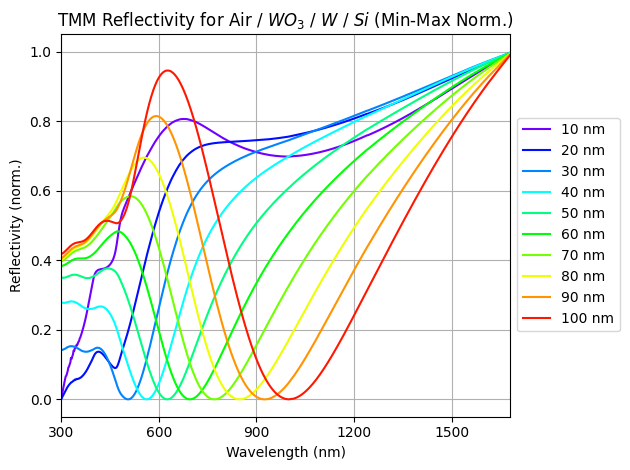

In [3]:
def refract_index_REDO(eps_real, eps_im):
    eps_complex = eps_real + 1j * eps_im
    n_complex = np.sqrt(eps_complex) 
    return n_complex 

#going to start off by just calculating it for one wavelength, and one oxide thickness 

#initializing variables that will always be constant/need to be outside of the loop 
thick_metal = 20 #in units of nm
n_air = 1 #index of refraction of air 

#initializing the General Reflectivity array, Oxide thickness array, and Input wavelengths
thickness_oxide = np.arange(10, 110, 10) #also in units of nm, the oxide thicknesses. 

inp_wl = wl_exp_array_filtered #the wavelengths I'm going to be using for the calculations 
#inp_wl = wl_exp_array

theta_incident = (np.pi / 180) * 0 # You can either put in your incident angle directly as radians or put it in as degrees and then convert it to radians. 
reflectivity = []

#Ruthenium Calculations 
for f, thickness in enumerate(thickness_oxide):
    reflectivity_at_this_thickness = []  # New list for each thickness
    d_array = np.array([inf, thickness, thick_metal, inf]) #thicknesses are all in units of nm --03-30-26-- 
    
    for i, wavelength in enumerate(inp_wl): 
        n_RuO2 = refract_index_REDO(e1_RuO2_array_filtered[i], e2_RuO2_array_filtered[i])
        n_Ru = refract_index_REDO(e1_Ru_array_filtered[i], e2_Ru_array_filtered[i]) #argument is eps_real and eps_imaginary of the dielectric function at that wavelength 

        #n_RuO2 = refract_index_REDO(e1_Ta2O5_array_filtered[i], e2_Ta2O5_array_filtered[i]) #just replace the arg
        #n_Ru = refract_index_REDO(e1_Ta_array_filtered[i], e2_Ta_array_filtered[i])

        #n_RuO2 = refract_index_REDO(e1_Ta2O5_array[i], e2_Ta2O5_array[i]) #just replace the arg  NON FILTERED
        #n_Ru = refract_index_REDO(e1_Ta_array[i], e2_Ta_array[i])

        #n_RuO2 = refract_index_REDO(e1_WO3_array_filtered[i], e2_WO3_array_filtered[i]) #just replace the arg
        #n_Ru = refract_index_REDO(e1_W_array_filtered[i], e2_W_array_filtered[i])
        
        n_si = n_new_si[i] + 1j * k_new_si[i]
        
        #addition #1 --03-30-26-- adding in n_list/array of refractive indices  
        n_array = np.array([n_air, n_RuO2, n_Ru, n_si])

        R_avg = unpolarized_RT(n_array, d_array, theta_incident, wavelength)[0] #extracting the reflectivity --03-30-26-- 
        reflectivity_at_this_thickness.append(R_avg)


    reflectivity.append(reflectivity_at_this_thickness)

      

# Plotting:
cmap = cm.get_cmap('gist_rainbow')
n = len(thickness_oxide)

for i, thickness in enumerate(thickness_oxide):
    #reflectivity_normalized = np.array(reflectivity[i]) / np.max(reflectivity[i]) #my original normalization 

    #trying out 'min-max' normalization
    reflectivity_normalized = np.array( (reflectivity[i] - np.min(reflectivity[i])) / (np.max(reflectivity[i]) - np.min(reflectivity[i])) )
    color = cmap(0.85 - 0.8 * i/(n-1))
    plt.plot(inp_wl, reflectivity_normalized, label=f'{thickness} nm', color = color)
  

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectivity (norm.)')
#plt.title(r'TMM Reflectivity for Air / $RuO_{2}$ / $Ru$ / $Si$ (Min-Max Norm.)')
#plt.title(r'TMM Reflectivity for Air / $Ta_{2}O_{5}$ / $Ta$ / $Si$ (Min-Max Norm.)')
plt.title(r'TMM Reflectivity for Air / $WO_{3}$ / $W$ / $Si$ (Min-Max Norm.)')
plt.xlim(300, 1680) # Specify both min and max
plt.grid(True)
plt.xticks([300, 600, 900, 1200, 1500])
plt.legend(bbox_to_anchor=(1.00, 0.8), loc='upper left')
plt.tight_layout() # prevents the legend from being cut off
plt.show()

https://medium.com/@mkc940/different-normalization-methods-a1be71fe9f1